# DreamGuard - VR Study Analysis

**Setup:**
```bash
uv sync                   # install dependencies
```

**Pull data from Quest:**
```bash
adb pull /sdcard/Android/data/com.DefaultCompany.DreamGuard/files/experiments data/experiments
```

Expected layout:
```
data/experiments/
  study_1/  study.csv  rooms.csv  collection.csv  position.csv  headset.csv  r_controller.csv  l_controller.csv
             performance/performance.csv
  study_2/  ...
```

In [1]:
from pathlib import Path
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from PIL import Image
from IPython.display import display, Image as IPyImage

warnings.filterwarnings('ignore')
%matplotlib inline

SCRIPTS_DIR      = Path('.').resolve()
DATA_DIR         = SCRIPTS_DIR.parent / 'data'
EXPERIMENTS_DIR  = DATA_DIR / 'experiments'
OUT_DIR          = DATA_DIR / 'analysis'
OUT_DIR.mkdir(exist_ok=True)

_img_candidates = [
    DATA_DIR / 'dungeon' / 'DungeonTopDown.png',
    SCRIPTS_DIR.parent / 'docs' / 'assets' / 'DungeonTopDown.png',
]
DUNGEON_IMG = next((p for p in _img_candidates if p.exists()), _img_candidates[-1])

# JSON may live in data/dungeon/ even when the image is in docs/assets/
_json_candidates = [
    DATA_DIR / 'dungeon' / 'DungeonTopDown.json',
    DUNGEON_IMG.with_suffix('.json'),
]
DUNGEON_JSON = next((p for p in _json_candidates if p.exists()), _json_candidates[-1])

assert EXPERIMENTS_DIR.exists(), f'data/experiments/ not found at {EXPERIMENTS_DIR}'
sessions = sorted(EXPERIMENTS_DIR.glob('study_*'), key=lambda p: int(p.name.split('_')[1]))
assert sessions, 'No study_* folders found in data/experiments/'
print(f'Found {len(sessions)} session(s): {[s.name for s in sessions]}')
print(f'Dungeon image : {DUNGEON_IMG}  (exists={DUNGEON_IMG.exists()})')
print(f'Dungeon JSON  : {DUNGEON_JSON} (exists={DUNGEON_JSON.exists()})')
print(f'Output dir    : {OUT_DIR}')

Found 4 session(s): ['study_0', 'study_1', 'study_2', 'study_3']
Dungeon image : F:\Unity\Projects\DreamGuard\docs\assets\DungeonTopDown.png  (exists=True)
Dungeon JSON  : F:\Unity\Projects\DreamGuard\data\dungeon\DungeonTopDown.json (exists=True)
Output dir    : F:\Unity\Projects\DreamGuard\data\analysis


## Load all sessions

In [2]:
def read_csv(session_dir: Path, name: str) -> pd.DataFrame:
    p = session_dir / name
    if not p.exists():
        return pd.DataFrame()
    df = pd.read_csv(p)
    if 'timestamp_iso' in df.columns:
        df['timestamp_iso'] = pd.to_datetime(df['timestamp_iso'])
    return df

def extract(detail: str, key: str) -> str:
    if pd.isna(detail):
        return ''
    for part in str(detail).split():
        if part.startswith(f'{key}='):
            return part[len(key)+1:]
    return ''

def nearest_pos(pos_df: pd.DataFrame, ts: pd.Timestamp):
    """Return the (x, z) position sample closest to timestamp ts."""
    if pos_df.empty:
        return None, None
    idx = (pos_df['timestamp_iso'] - ts).abs().idxmin()
    r = pos_df.loc[idx]
    return r['x'], r['z']

# Room → passthrough technique (fixed order, within-subjects design)
ROOM_TECHNIQUE = {
    'room_1': 'Guardian Grid',
    'room_2': 'Window',
    'room_3': 'Window + Detection',
    'room_4': 'Depth Bubble',
}
TECHNIQUE_ORDER = list(ROOM_TECHNIQUE.values())

data = {}
for sd in sessions:
    data[sd.name] = {
        'dir':        sd,
        'study':      read_csv(sd, 'study.csv'),
        'rooms':      read_csv(sd, 'rooms.csv'),
        'collection': read_csv(sd, 'collection.csv'),
        'position':   read_csv(sd, 'position.csv'),
        'headset':    read_csv(sd, 'headset.csv'),
        'r_ctrl':     read_csv(sd, 'r_controller.csv'),
        'l_ctrl':     read_csv(sd, 'l_controller.csv'),
        'performance': read_csv(sd, 'performance.csv'),
    }

print('Loaded.')
print(f'Technique order: {TECHNIQUE_ORDER}')

Loaded.
Technique order: ['Guardian Grid', 'Window', 'Window + Detection', 'Depth Bubble']


## Session Overview

In [3]:
rows = []
for name, d in data.items():
    s = d['study']
    if s.empty:
        continue
    t0 = s[s.event_type == 'SESSION_START']['timestamp_iso']
    t1 = s[s.event_type == 'SESSION_END']['timestamp_iso']
    t0 = t0.iloc[0] if not t0.empty else s.timestamp_iso.min()
    t1 = t1.iloc[0] if not t1.empty else s.timestamp_iso.max()
    rows.append({
        'session':         name,
        'participant':     s['participant_id'].dropna().iloc[0],
        'duration_min':    round((t1 - t0).total_seconds() / 60, 1),
        'rooms_complete':  (s.event_type == 'ROOM_COMPLETE').sum(),
        'orbs_collected':  len(d['collection']),
        'triggers':        (s.event_type == 'TRIGGER').sum(),
        'intrusions':      (s.event_type == 'INTRUSION_MARK').sum(),
        'false_positives': (s.event_type == 'FALSE_POSITIVE').sum(),
        'pos_samples':     len(d['position']),
    })

overview = pd.DataFrame(rows)
display(overview)

,session,participant,duration_min,rooms_complete,orbs_collected,triggers,intrusions,false_positives,pos_samples
0,study_0,P00,3.6,4,16,5,0,0,13024
1,study_1,P00,5.8,4,16,5,0,0,16427
2,study_2,P00,5.6,4,16,5,0,0,22622
3,study_3,P00,5.7,4,16,5,0,0,19613


## Trigger Latency

,session,participant,room_id,technique,latency_s,trigger_technique
0,study_0,P00,room_1,Guardian Grid,0.002,default
1,study_0,P00,room_2,Window,0.003,default
2,study_0,P00,room_3,Window + Detection,0.025,default
3,study_0,P00,room_4,Depth Bubble,0.003,default
4,study_1,P00,room_1,Guardian Grid,0.002,default
5,study_1,P00,room_2,Window,0.002,default
6,study_1,P00,room_3,Window + Detection,0.027,default
7,study_1,P00,room_4,Depth Bubble,0.005,default
8,study_2,P00,room_1,Guardian Grid,0.001,default
9,study_2,P00,room_2,Window,0.003,default


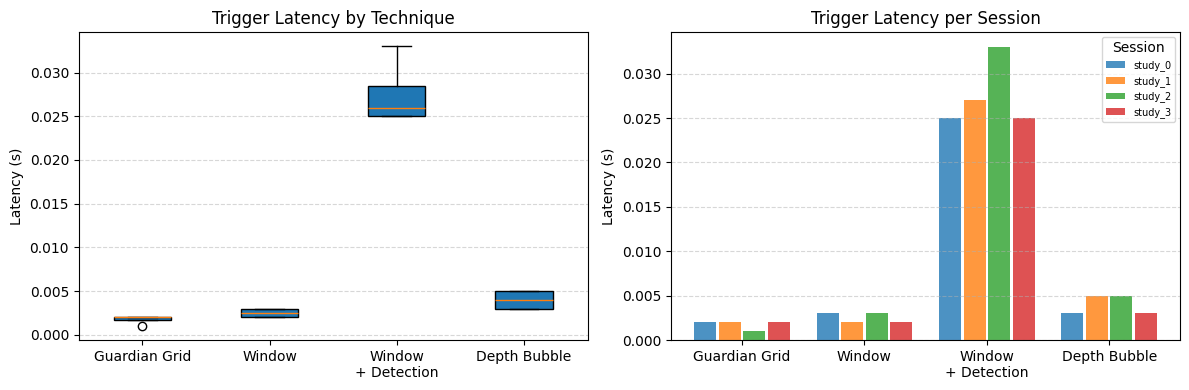

In [4]:
latency_rows = []
for name, d in data.items():
    s = d['study']
    if s.empty:
        continue
    halfways = s[s.event_type == 'ROOM_HALFWAY'].copy()
    triggers  = s[s.event_type == 'TRIGGER'].copy()
    halfways['room_id'] = halfways['detail'].apply(lambda x: extract(x, 'room_id'))
    pid = s['participant_id'].dropna().iloc[0]
    for _, hw in halfways.iterrows():
        later = triggers[triggers.timestamp_iso > hw.timestamp_iso]
        if later.empty:
            continue
        trig = later.iloc[0]
        room_id = hw['room_id']
        latency_rows.append({
            'session':           name,
            'participant':       pid,
            'room_id':           room_id,
            'technique':         ROOM_TECHNIQUE.get(room_id, room_id),
            'latency_s':         (trig.timestamp_iso - hw.timestamp_iso).total_seconds(),
            'trigger_technique': extract(trig['detail'], 'technique'),
        })

latency_df = pd.DataFrame(latency_rows)

if latency_df.empty:
    print('No trigger latency data yet.')
else:
    display(latency_df)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: box plot by technique
    groups = [latency_df[latency_df.technique == t]['latency_s'].values for t in TECHNIQUE_ORDER]
    axes[0].boxplot(groups, labels=[t.replace(' + ', '\n+ ') for t in TECHNIQUE_ORDER], patch_artist=True)
    axes[0].set_ylabel('Latency (s)')
    axes[0].set_title('Trigger Latency by Technique')
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Right: latency per session (to see consistency across runs)
    sessions_list = sorted(latency_df['session'].unique())
    colors = plt.cm.tab10.colors
    x = np.arange(len(TECHNIQUE_ORDER))
    w = 0.8 / max(len(sessions_list), 1)
    for i, sess in enumerate(sessions_list):
        sub = latency_df[latency_df.session == sess].set_index('technique')
        vals = [sub.loc[t, 'latency_s'] if t in sub.index else np.nan for t in TECHNIQUE_ORDER]
        axes[1].bar(x + i*w, vals, w*0.9, label=sess, color=colors[i], alpha=0.8)
    axes[1].set_xticks(x + w*(len(sessions_list)-1)/2)
    axes[1].set_xticklabels([t.replace(' + ', '\n+ ') for t in TECHNIQUE_ORDER])
    axes[1].set_ylabel('Latency (s)')
    axes[1].set_title('Trigger Latency per Session')
    axes[1].legend(title='Session', fontsize=7)
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'latency.png', dpi=150, bbox_inches='tight')
    plt.show()

## Room Durations

,session,participant,room_id,technique,duration_s
0,study_0,P00,room_1,Guardian Grid,46.955
1,study_0,P00,room_2,Window,43.476
2,study_0,P00,room_3,Window + Detection,50.096
3,study_0,P00,room_4,Depth Bubble,53.868
4,study_1,P00,room_1,Guardian Grid,77.058
5,study_1,P00,room_2,Window,69.993
6,study_1,P00,room_3,Window + Detection,72.769
7,study_1,P00,room_4,Depth Bubble,66.350
8,study_2,P00,room_1,Guardian Grid,62.801
9,study_2,P00,room_2,Window,85.484


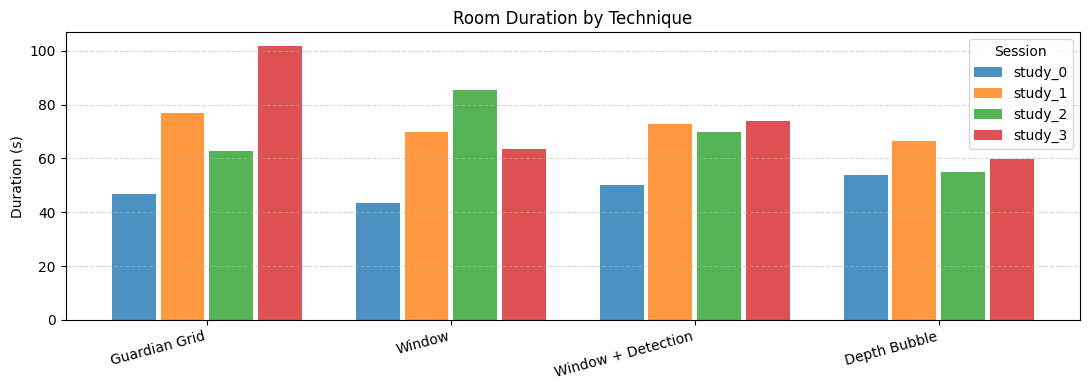

In [5]:
dur_rows = []
for name, d in data.items():
    rooms = d['rooms']
    s     = d['study']
    if rooms.empty or s.empty:
        continue
    pid = s['participant_id'].dropna().iloc[0]
    enters = rooms[rooms.event == 'ENTER'].set_index('room_id')['timestamp_iso']
    exits  = rooms[rooms.event == 'EXIT'].set_index('room_id')['timestamp_iso']
    for room_id in enters.index.intersection(exits.index):
        dur_rows.append({
            'session':    name,
            'participant': pid,
            'room_id':    room_id,
            'technique':  ROOM_TECHNIQUE.get(room_id, room_id),
            'duration_s': (exits[room_id] - enters[room_id]).total_seconds(),
        })

dur_df = pd.DataFrame(dur_rows)

if dur_df.empty:
    print('No room duration data yet.')
else:
    display(dur_df)
    sessions_list = sorted(dur_df['session'].unique())
    room_ids      = sorted(dur_df['room_id'].unique())
    x = np.arange(len(room_ids))
    w = 0.8 / max(len(sessions_list), 1)

    fig, ax = plt.subplots(figsize=(11, 4))
    for i, sess in enumerate(sessions_list):
        sub   = dur_df[dur_df.session == sess].set_index('room_id')
        means = [sub.loc[r, 'duration_s'] if r in sub.index else 0 for r in room_ids]
        ax.bar(x + i*w, means, w*0.9, label=sess, alpha=0.8)

    ax.set_xticks(x + w*(len(sessions_list)-1)/2)
    ax.set_xticklabels([ROOM_TECHNIQUE.get(r, r) for r in room_ids], rotation=15, ha='right')
    ax.set_ylabel('Duration (s)')
    ax.set_title('Room Duration by Technique')
    ax.legend(title='Session')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'room_durations.png', dpi=150, bbox_inches='tight')
    plt.show()

## Minimap Setup

World-space bounds are auto-derived from position data (Unity X = horizontal, Z = depth / up in top-down view).

Each room panel uses **square display bounds** (`ROOM_DISPLAY`) centered on the room's trajectory centroid, with a uniform half-size across all rooms. This prevents squishing regardless of per-room Z extent variation. `ROOM_BOUNDS` is kept unchanged for data filtering.

- `_BG_ZOOM_FRAC` — extra fractional padding beyond the max trajectory extent (default 0.05 = 5%, shows outer walls)

If room_4's background is cut off on the right, the dungeon screenshot doesn't cover Z > 73.75 — re-run **Tools > DreamGuard > Dungeon Top-Down Screenshot** in Unity to update it.

In [6]:
dungeon_img = None
if DUNGEON_IMG.exists():
    dungeon_img = Image.open(DUNGEON_IMG).convert('RGBA')
    print(f'Dungeon image: {dungeon_img.size[0]}×{dungeon_img.size[1]} px  ({DUNGEON_IMG})')
else:
    print(f'WARNING: Dungeon image not found at {DUNGEON_IMG}')

# ── World bounds from DungeonTopDown.json ────────────────────────────────────
if DUNGEON_JSON.exists():
    cam = json.loads(DUNGEON_JSON.read_text())
    ortho  = cam['ortho_size']
    aspect = cam['aspect']
    WORLD_XMIN = cam['center_x'] - ortho * aspect
    WORLD_XMAX = cam['center_x'] + ortho * aspect
    WORLD_ZMIN = cam['center_z'] - ortho
    WORLD_ZMAX = cam['center_z'] + ortho
    print(f'Camera: center=({cam["center_x"]:.2f}, {cam["center_z"]:.2f})  orthoSize={ortho:.2f}  aspect={aspect}')
else:
    print('WARNING: DungeonTopDown.json not found — re-run Tools > DreamGuard > Dungeon Top-Down Screenshot.')
    all_pos = pd.concat([d['position'] for d in data.values() if not d['position'].empty], ignore_index=True)
    if all_pos.empty:
        WORLD_XMIN, WORLD_XMAX = -10.0, 10.0
        WORLD_ZMIN, WORLD_ZMAX = -5.0, 40.0
    else:
        pad_x = max((all_pos['x'].max() - all_pos['x'].min()) * 0.05, 1.0)
        pad_z = max((all_pos['z'].max() - all_pos['z'].min()) * 0.05, 1.0)
        WORLD_XMIN = all_pos['x'].min() - pad_x; WORLD_XMAX = all_pos['x'].max() + pad_x
        WORLD_ZMIN = all_pos['z'].min() - pad_z; WORLD_ZMAX = all_pos['z'].max() + pad_z

print(f'World bounds — X: [{WORLD_XMIN:.2f}, {WORLD_XMAX:.2f}]  Z: [{WORLD_ZMIN:.2f}, {WORLD_ZMAX:.2f}]')

# ── Per-room bounds (used for event filtering) ────────────────────────────────
def _compute_room_bounds_raw(data: dict) -> dict:
    room_pos: dict[str, list] = {}
    for d in data.values():
        pos   = d['position']
        rooms = d['rooms']
        if pos.empty or rooms.empty:
            continue
        enters = rooms[rooms.event == 'ENTER'].set_index('room_id')['timestamp_iso']
        exits  = rooms[rooms.event == 'EXIT'].set_index('room_id')['timestamp_iso']
        for rid in enters.index.intersection(exits.index):
            mask = (pos.timestamp_iso >= enters[rid]) & (pos.timestamp_iso <= exits[rid])
            sub  = pos[mask]
            if not sub.empty:
                room_pos.setdefault(rid, []).append(sub)
    raw = {}
    for rid, dfs in room_pos.items():
        all_df = pd.concat(dfs)
        raw[rid] = dict(xmin=float(all_df.x.min()), xmax=float(all_df.x.max()),
                        zmin=float(all_df.z.min()), zmax=float(all_df.z.max()))
    return raw

_raw = _compute_room_bounds_raw(data)
SORTED_ROOMS = sorted(_raw, key=lambda r: _raw[r]['zmin'])
print(f'Room bounds: {len(SORTED_ROOMS)} rooms' if _raw else 'No per-room position data.')

# ── Tight display bounds from position data ───────────────────────────────────
_all_pos_df = pd.concat([d['position'] for d in data.values() if not d['position'].empty], ignore_index=True)
_DISP_PAD = 2.0  # world-unit padding around traversed area
DISP_XMIN = _all_pos_df['x'].min() - _DISP_PAD
DISP_XMAX = _all_pos_df['x'].max() + _DISP_PAD
DISP_ZMIN = _all_pos_df['z'].min() - _DISP_PAD
DISP_ZMAX = _all_pos_df['z'].max() + _DISP_PAD
print(f'Display bounds — X: [{DISP_XMIN:.2f}, {DISP_XMAX:.2f}]  Z: [{DISP_ZMIN:.2f}, {DISP_ZMAX:.2f}]')

# ── Dungeon image array (kept at full world extent for imshow mapping) ────────
_dungeon_arr = np.array(dungeon_img) if dungeon_img is not None else None

# Make black background transparent (composites against ax facecolor = black,
# so the saved PNG and notebook display match regardless of Jupyter theme)
if _dungeon_arr is not None:
    dark_mask = _dungeon_arr[..., :3].max(axis=2) < 20
    _dungeon_arr = _dungeon_arr.copy()
    _dungeon_arr[dark_mask, 3] = 0
    _bg_img = np.rot90(_dungeon_arr, k=-1)
    print(f'Image prepared: {_dungeon_arr.shape[1]}×{_dungeon_arr.shape[0]} px (black bg → transparent)')
else:
    _bg_img = None

# ── Figure / drawing helpers ──────────────────────────────────────────────────
def make_full_fig():
    """Figure sized to the tight display bounds (Z horizontal, X vertical)."""
    z_span = DISP_ZMAX - DISP_ZMIN
    x_span = DISP_XMAX - DISP_XMIN
    base = 18
    scale = base / max(z_span, x_span)
    fig, ax = plt.subplots(figsize=(max(z_span * scale, 6), max(x_span * scale, 5)),
                           layout='constrained')
    return fig, ax

def draw_bg_full(ax):
    """Draw the dungeon background clipped to the tight display bounds."""
    # Black axes background so transparent dungeon pixels composite correctly
    # in both the notebook and saved PNGs (avoids white-washout on save).
    ax.set_facecolor('black')
    if _bg_img is not None:
        ax.imshow(_bg_img,
                  extent=[WORLD_ZMIN, WORLD_ZMAX, WORLD_XMIN, WORLD_XMAX],
                  origin='lower', zorder=0, interpolation='bilinear')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(DISP_ZMIN, DISP_ZMAX)
    ax.set_ylim(DISP_XMIN, DISP_XMAX)
    ax.set_xlabel('Z')
    ax.set_ylabel('X')

def make_heatmap_full(dfs, resolution=600):
    xs = np.concatenate([df['x'].values for df in dfs])
    zs = np.concatenate([df['z'].values for df in dfs])
    hm, _, _ = np.histogram2d(xs, zs, bins=resolution,
                               range=[[WORLD_XMIN, WORLD_XMAX], [WORLD_ZMIN, WORLD_ZMAX]])
    return hm

def overlay_heatmap_full(ax, hm, alpha=0.6):
    masked = np.ma.masked_where(hm == 0, hm)
    cmap   = plt.cm.hot_r.copy(); cmap.set_bad(alpha=0.0)
    vmax   = max(hm.max(), 1)
    norm   = mcolors.PowerNorm(gamma=0.4, vmin=1, vmax=vmax)
    ax.imshow(masked, extent=[WORLD_ZMIN, WORLD_ZMAX, WORLD_XMIN, WORLD_XMAX],
              origin='lower', cmap=cmap, alpha=alpha, zorder=1, norm=norm,
              interpolation='bilinear')
    return cmap, norm

EVENT_STYLES = {
    'ROOM_ENTER':       dict(marker='o',  color='#2196F3', ms=10, zorder=4, label='Room enter'),
    'ROOM_HALFWAY':     dict(marker='v',  color='#9C27B0', ms=10, zorder=4, label='Room halfway'),
    'ROOM_COMPLETE':    dict(marker='s',  color='#1565C0', ms=10, zorder=4, label='Room complete'),
    'INTRUSION_MARK':   dict(marker='^',  color='#F44336', ms=12, zorder=5, label='Intrusion'),
    'TRIGGER':          dict(marker='*',  color='#E91E63', ms=15, zorder=5, label='Trigger'),
    'FALSE_POSITIVE':   dict(marker='x',  color='#FF5722', ms=12, zorder=5, label='False positive'),
    'CONFEDERATE_EXIT': dict(marker='D',  color='#795548', ms=9,  zorder=4, label='Confederate exit'),
}

def legend_handle(etype: str) -> Line2D:
    st = EVENT_STYLES[etype]
    return Line2D([0],[0], marker=st['marker'], color='w',
                  markerfacecolor=st['color'], markersize=8,
                  label=st['label'], markeredgecolor='black', markeredgewidth=0.5)

print('Minimap setup complete.')


Dungeon image: 2048×2048 px  (F:\Unity\Projects\DreamGuard\docs\assets\DungeonTopDown.png)
Camera: center=(0.25, 23.25)  orthoSize=50.50  aspect=1
World bounds — X: [-50.25, 50.75]  Z: [-27.25, 73.75]
Room bounds: 4 rooms
Display bounds — X: [-12.95, 13.45]  Z: [-25.92, 72.45]
Image prepared: 2048×2048 px (black bg → transparent)
Minimap setup complete.


## Minimap — Player Trajectory per Session

Path colour = time (purple → yellow). Symbols mark key events at the player's nearest recorded position.

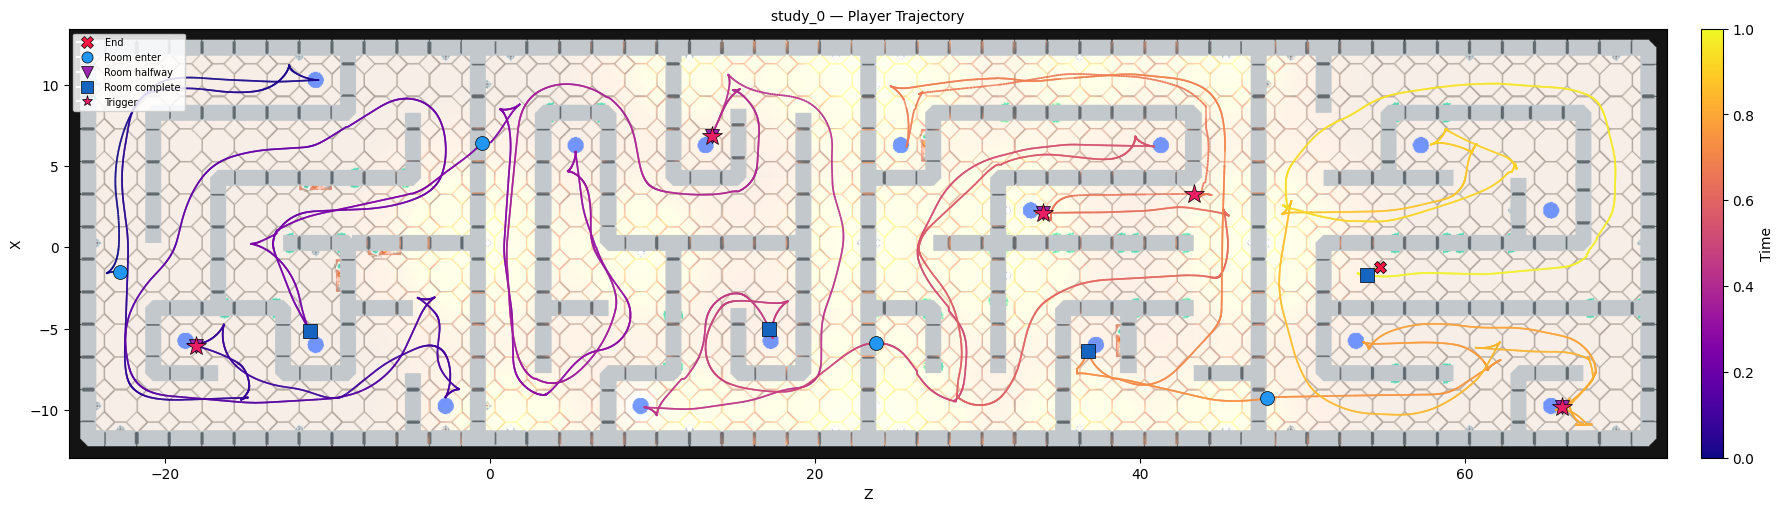

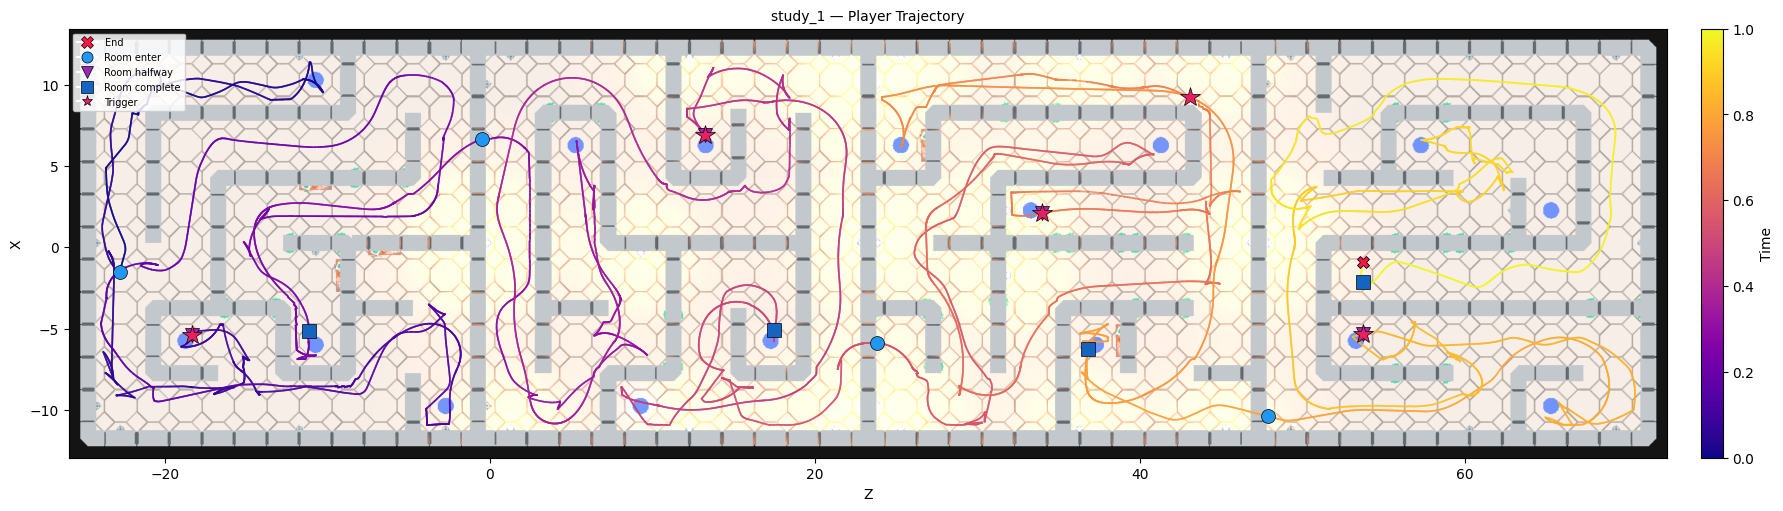

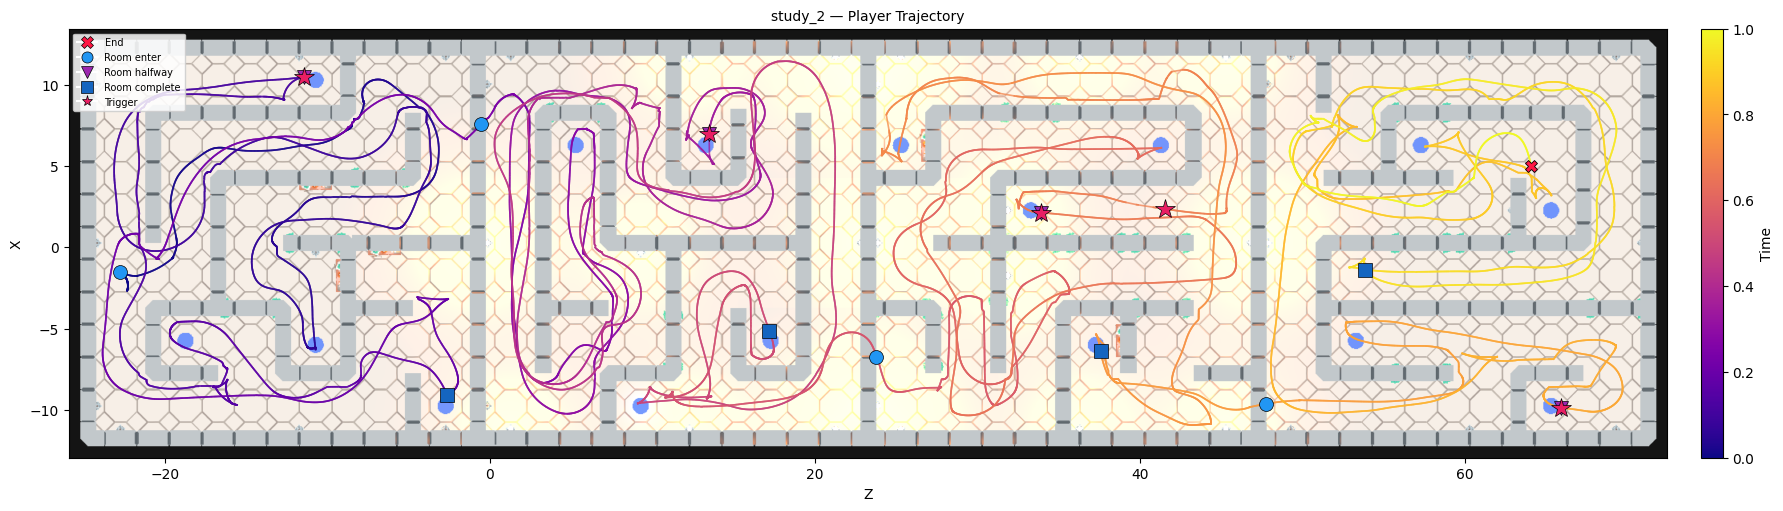

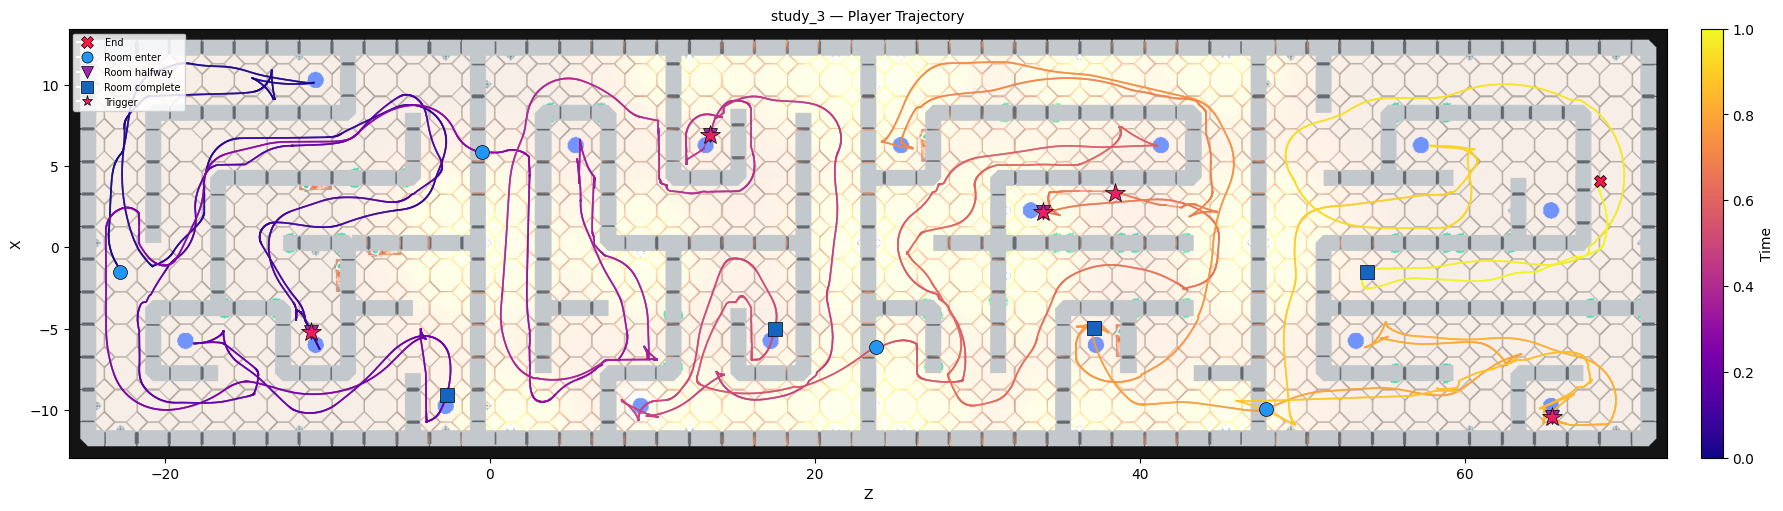

In [7]:
with_pos = [(n, d) for n, d in data.items() if not d['position'].empty]
if not with_pos:
    print('No position data.')
else:
    for name, d in with_pos:
        fig, ax = make_full_fig()
        draw_bg_full(ax)

        study = d['study']
        rooms = d['rooms']
        pos   = d['position']

        # Exclude bootloader movement before the first room enter
        first_enters = rooms[rooms.event == 'ENTER']['timestamp_iso']
        if not first_enters.empty:
            pos = pos[pos.timestamp_iso >= first_enters.min()]

        xs, zs = pos['x'].values, pos['z'].values
        t = np.linspace(0, 1, len(xs))

        for j in range(len(xs) - 1):
            ax.plot(zs[j:j+2], xs[j:j+2],
                    color=cm.plasma(t[j]), lw=1.2, alpha=0.75, zorder=2)
        if len(xs):
            ax.plot(zs[-1], xs[-1], 'X', color='#FF1744', ms=9, zorder=6,
                    markeredgecolor='black', markeredgewidth=0.6, linestyle='None')

        legend_pool = {}
        for etype, st in EVENT_STYLES.items():
            for _, ev in study[study.event_type == etype].iterrows():
                px, pz = nearest_pos(pos, ev.timestamp_iso)
                if px is None:
                    continue
                ax.plot(pz, px, marker=st['marker'], color=st['color'],
                        markersize=st['ms'], zorder=st['zorder'],
                        markeredgecolor='black', markeredgewidth=0.5, linestyle='None')
                legend_pool.setdefault(etype, legend_handle(etype))

        sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, 1))
        sm.set_array([])
        fig.colorbar(sm, ax=ax, label='Time', fraction=0.04, pad=0.02)

        extra = [
            Line2D([0],[0], marker='X', color='w', markerfacecolor='#FF1744',
                   markersize=8, label='End', markeredgecolor='black', markeredgewidth=0.5),
        ]
        all_handles = extra + list(legend_pool.values())
        ax.legend(handles=all_handles,
                  loc='upper left',
                  ncol=1,
                  fontsize=7, framealpha=0.85)

        ax.set_title(f'{name} — Player Trajectory', fontsize=10)
        plt.savefig(OUT_DIR / f'{name}_trajectory.png', dpi=200, bbox_inches='tight')
        plt.show()


## Minimap — Heatmap Overlay (Combined)

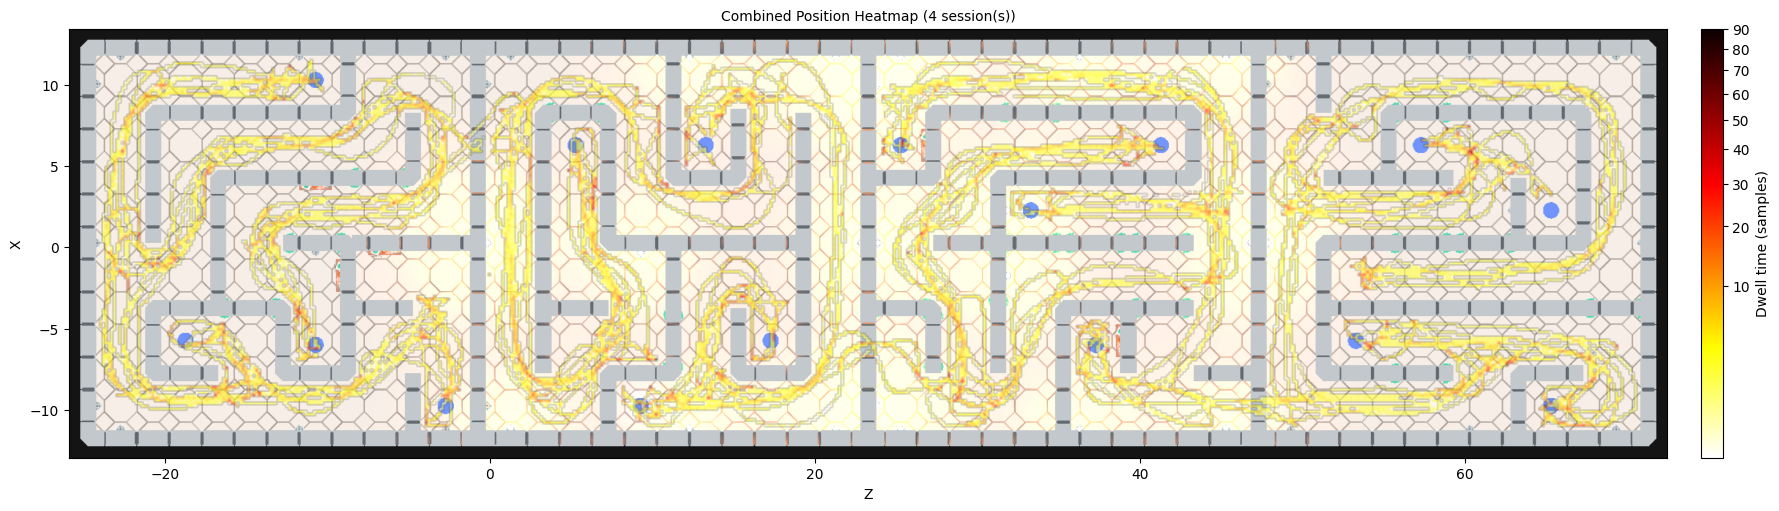

In [8]:
pos_dfs = [d['position'] for d in data.values() if not d['position'].empty]

if not pos_dfs:
    print('No position data.')
else:
    fig, ax = make_full_fig()
    draw_bg_full(ax)
    hm = make_heatmap_full(pos_dfs)
    cmap, norm = overlay_heatmap_full(ax, hm)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='Dwell time (samples)', fraction=0.04, pad=0.02)
    ax.set_title(f'Combined Position Heatmap ({len(pos_dfs)} session(s))', fontsize=10)
    plt.savefig(OUT_DIR / 'heatmap_combined.png', dpi=200, bbox_inches='tight')
    plt.show()


## Minimap — Intrusion → Trigger Positions

Where intrusions occurred and where the technique fired. Arrows connect the two events for the same episode.

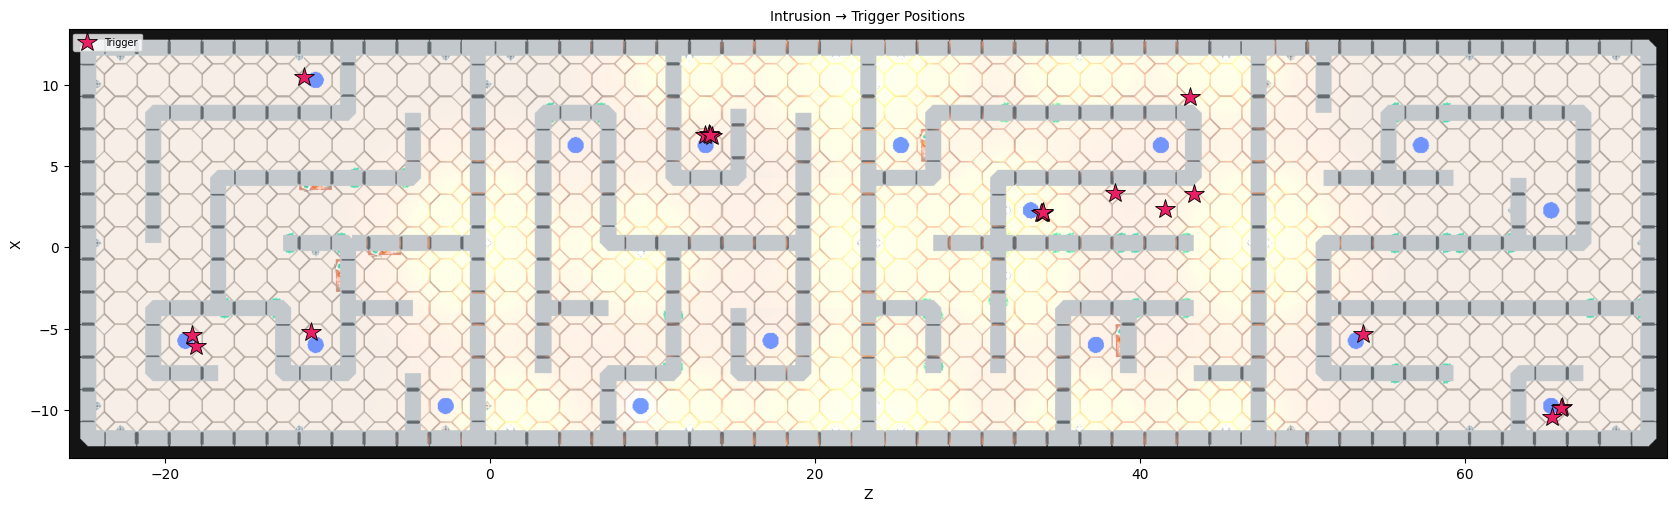

In [9]:
fig, ax = make_full_fig()
draw_bg_full(ax)
seen = set()

for name, d in data.items():
    s, pos = d['study'], d['position']
    if s.empty or pos.empty:
        continue

    for etype in ('INTRUSION_MARK', 'TRIGGER', 'FALSE_POSITIVE'):
        st = EVENT_STYLES[etype]
        for _, ev in s[s.event_type == etype].iterrows():
            px, pz = nearest_pos(pos, ev.timestamp_iso)
            if px is None:
                continue
            lbl = st['label'] if etype not in seen else '_nolegend_'
            seen.add(etype)
            ax.plot(pz, px, marker=st['marker'], color=st['color'],
                    markersize=st['ms'], zorder=st['zorder'],
                    markeredgecolor='black', markeredgewidth=0.6,
                    linestyle='None', label=lbl)

    intrusions = s[s.event_type == 'INTRUSION_MARK']
    triggers   = s[s.event_type == 'TRIGGER']
    for _, intr in intrusions.iterrows():
        later = triggers[triggers.timestamp_iso > intr.timestamp_iso]
        if later.empty:
            continue
        trig = later.iloc[0]
        ix, iz = nearest_pos(pos, intr.timestamp_iso)
        tx, tz = nearest_pos(pos, trig.timestamp_iso)
        if ix is not None:
            ax.annotate('', xy=(tz, tx), xytext=(iz, ix),
                        arrowprops=dict(arrowstyle='->', color='white', lw=1.5), zorder=7)

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(),
              loc='upper left', fontsize=7)

ax.set_title('Intrusion → Trigger Positions', fontsize=10)
plt.savefig(OUT_DIR / 'minimap_intrusion_triggers.png', dpi=200, bbox_inches='tight')
plt.show()


## Minimap — Headset Gaze Direction

Arrows show where the participant was looking (XZ projection), sampled every N frames.

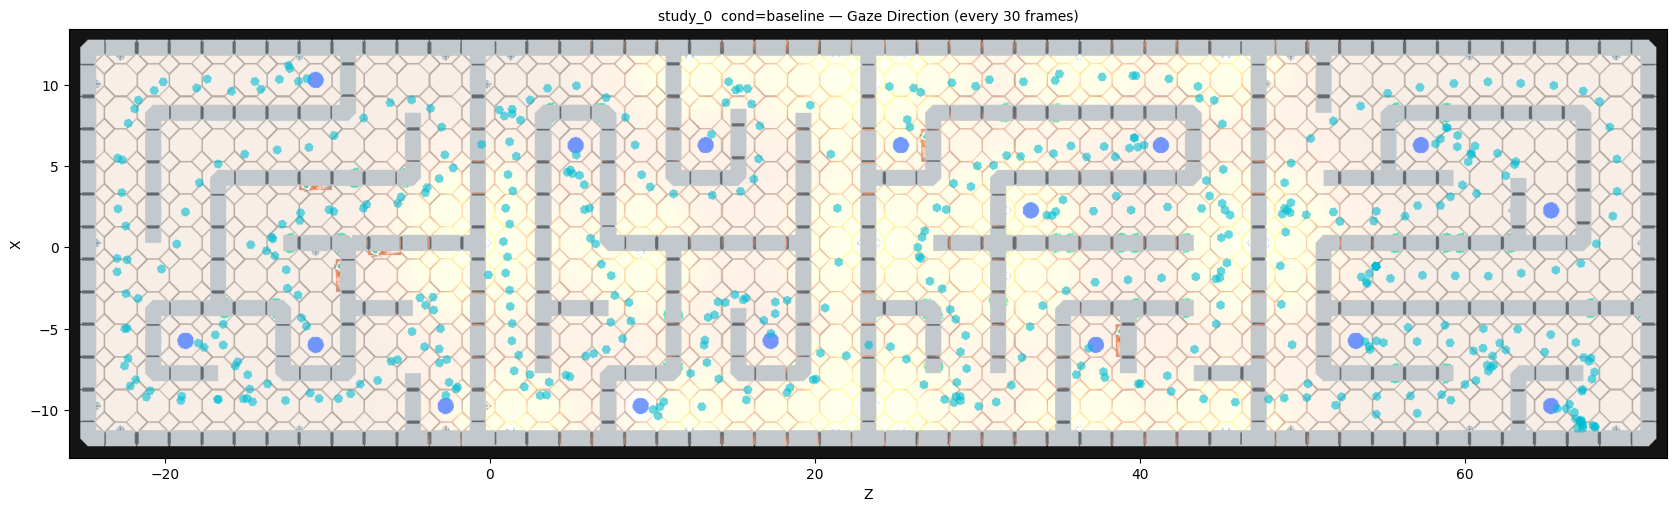

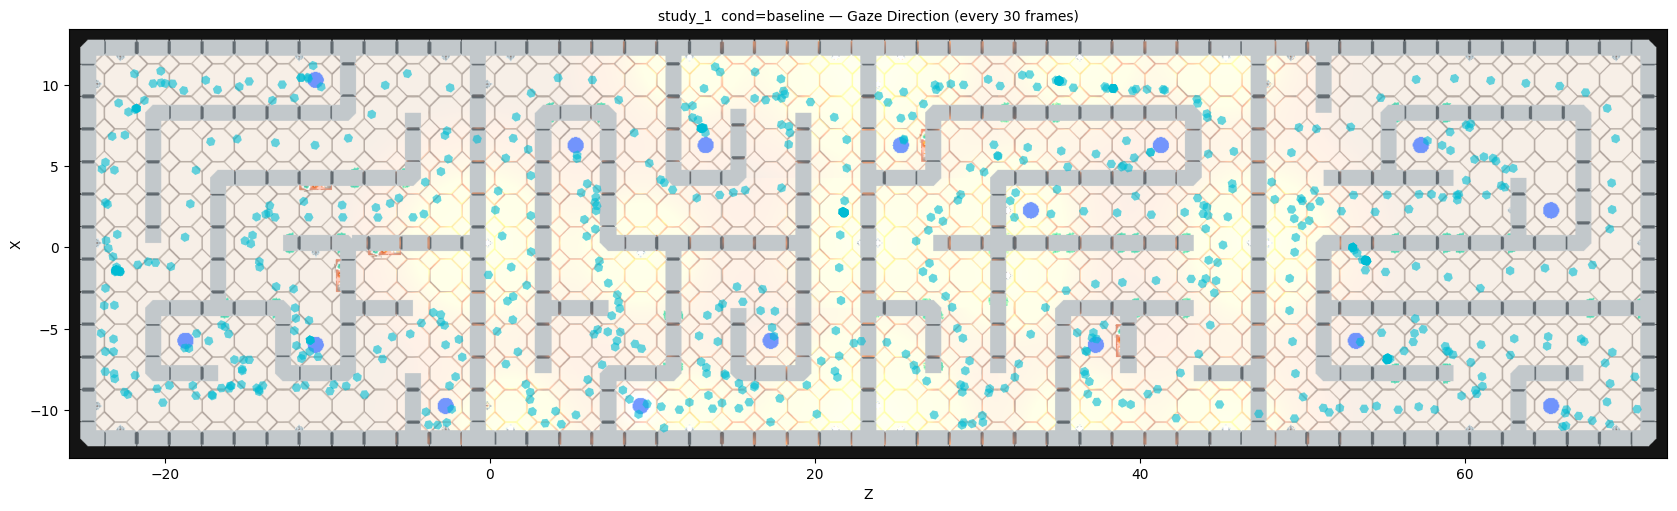

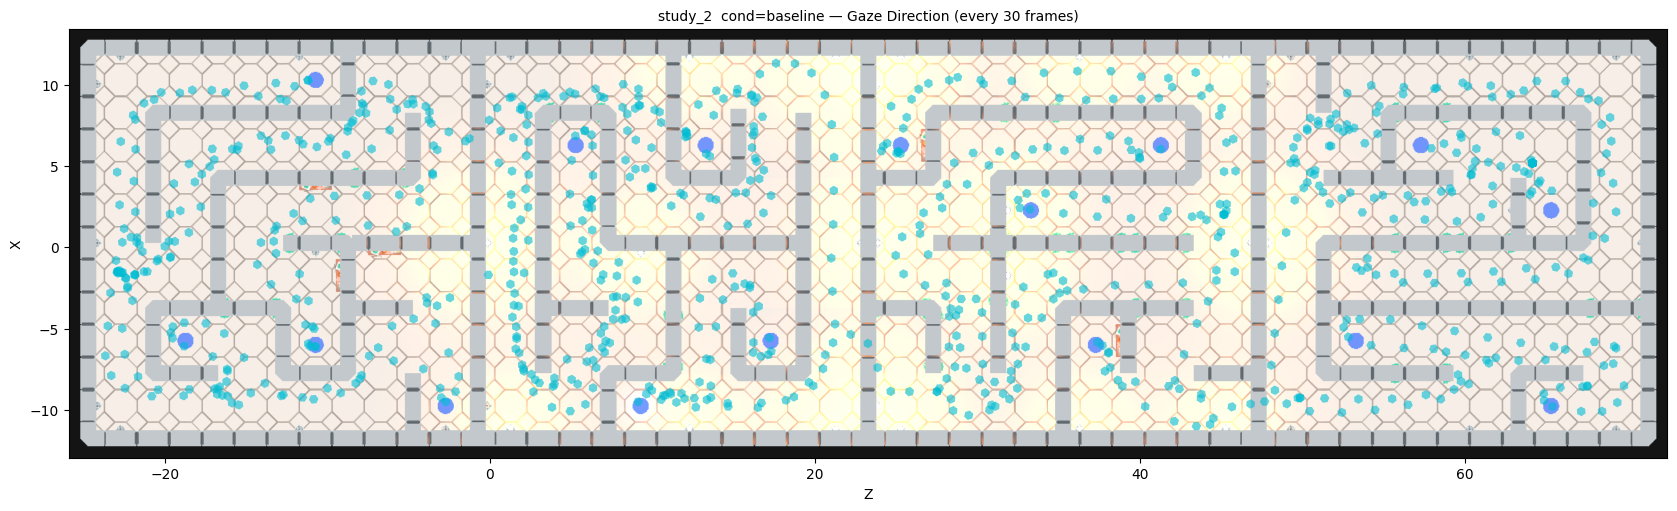

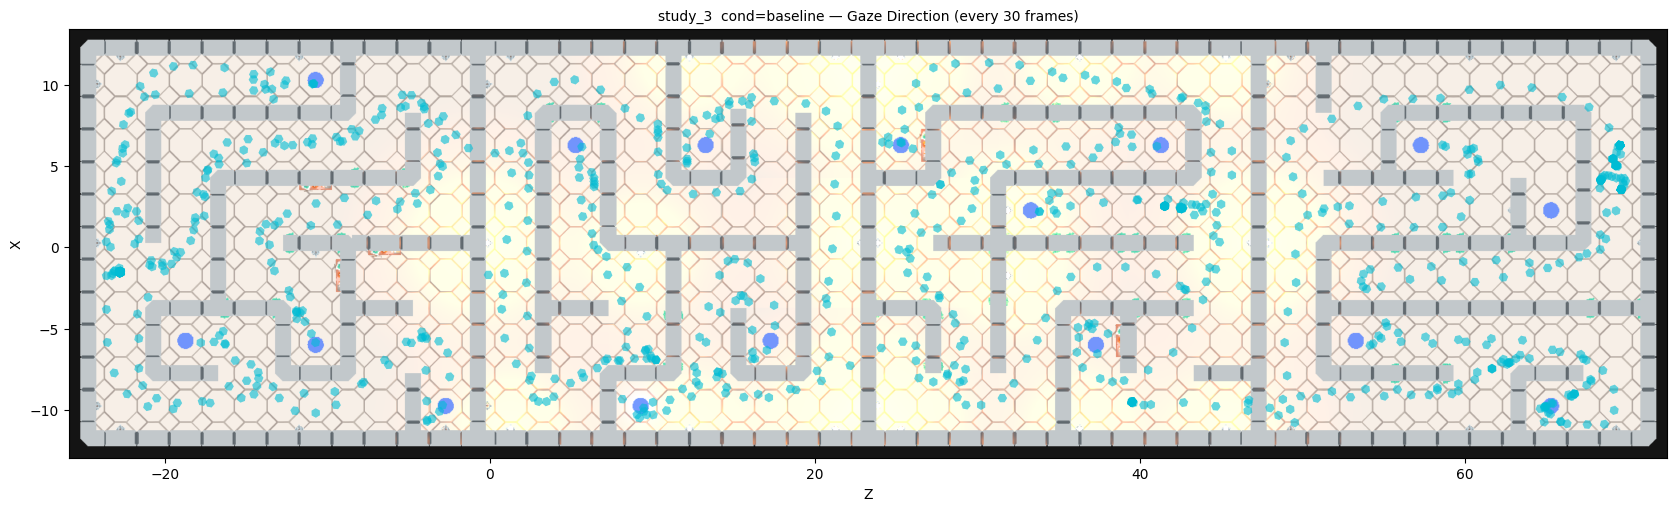

In [10]:
def quat_forward_xz(qx, qy, qz, qw):
    """Rotate Unity's forward vector (0,0,1) by quaternion; return (fx, fz)."""
    fx = 2*(qx*qz + qw*qy)
    fz = 2*(qy*qz - qw*qx)
    mag = np.sqrt(fx**2 + fz**2) + 1e-9
    return fx/mag, fz/mag

ARROW_STEP   = 30   # every Nth headset sample
ARROW_LENGTH = 0.4  # world units

with_head = [(n, d) for n, d in data.items() if not d['headset'].empty]
if not with_head:
    print('No headset data.')
else:
    for name, d in with_head:
        fig, ax = make_full_fig()
        draw_bg_full(ax)

        study = d['study']
        head  = d['headset'].iloc[::ARROW_STEP].copy()
        head['fx'], head['fz'] = zip(*head.apply(
            lambda r: quat_forward_xz(r.rot_x, r.rot_y, r.rot_z, r.rot_w), axis=1))

        # Axes are (Z horizontal, X vertical) — swap pos and direction components
        ax.quiver(
            head['pos_z'].values, head['pos_x'].values,
            head['fz'].values,    head['fx'].values,
            color='#00BCD4', alpha=0.6, scale=1/ARROW_LENGTH,
            scale_units='xy', angles='xy', width=0.006, zorder=3
        )

        cond = study['condition'].dropna().iloc[0] if not study.empty else '?'
        ax.set_title(f'{name}  cond={cond} — Gaze Direction (every {ARROW_STEP} frames)', fontsize=10)
        plt.savefig(OUT_DIR / 'minimap_headset_gaze.png', dpi=200, bbox_inches='tight')
        plt.show()


## Minimap — Gaze Heatmap (Combined)

Each headset sample's forward ray is projected `GAZE_PROJECT_DIST` world units ahead; the density of those look-at points is shown as a heatmap.

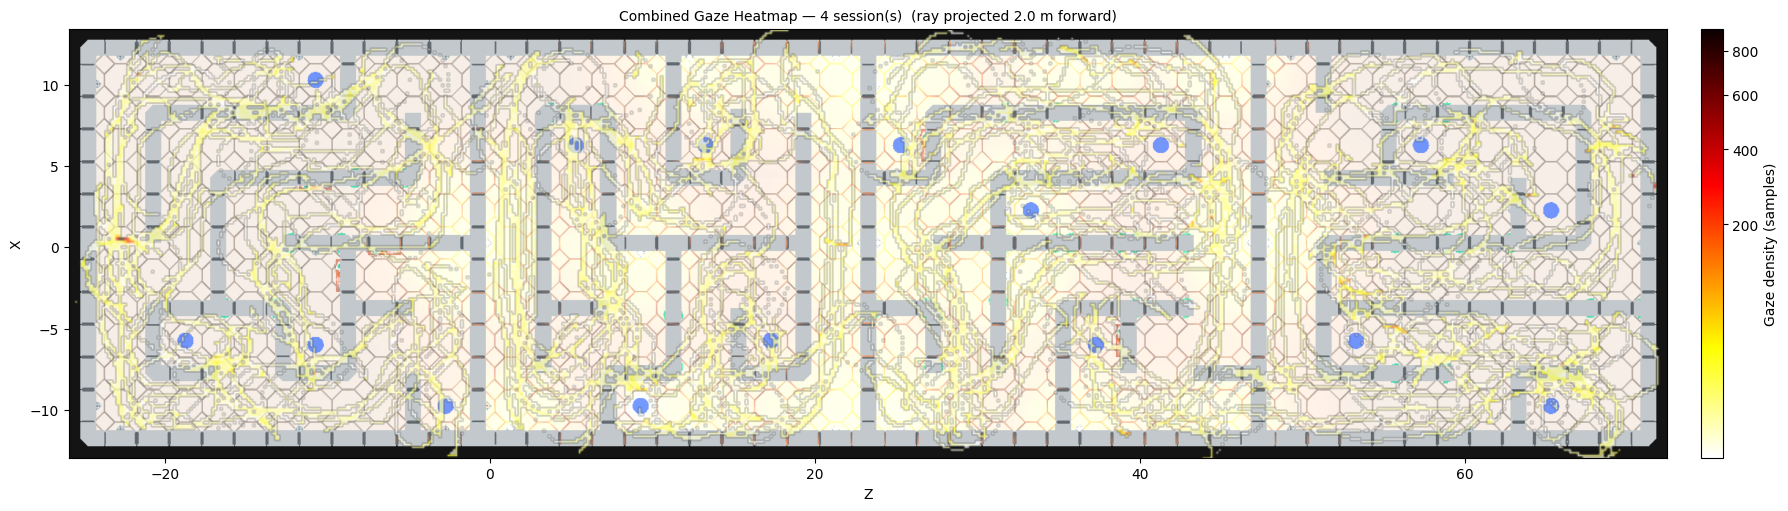

In [11]:
GAZE_PROJECT_DIST = 2.0  # world units to project each gaze ray forward

with_head = [(n, d) for n, d in data.items() if not d['headset'].empty]
if not with_head:
    print('No headset data.')
else:
    all_gx, all_gz = [], []
    for name, d in with_head:
        head = d['headset'].copy()
        head['fx'], head['fz'] = zip(*head.apply(
            lambda r: quat_forward_xz(r.rot_x, r.rot_y, r.rot_z, r.rot_w), axis=1))
        all_gx.append((head['pos_x'] + head['fx'] * GAZE_PROJECT_DIST).values)
        all_gz.append((head['pos_z'] + head['fz'] * GAZE_PROJECT_DIST).values)

    all_gx = np.concatenate(all_gx)
    all_gz = np.concatenate(all_gz)

    hm, _, _ = np.histogram2d(all_gx, all_gz, bins=600,
                               range=[[WORLD_XMIN, WORLD_XMAX], [WORLD_ZMIN, WORLD_ZMAX]])

    fig, ax = make_full_fig()
    draw_bg_full(ax)

    masked = np.ma.masked_where(hm == 0, hm)
    cmap = plt.cm.hot_r.copy(); cmap.set_bad(alpha=0.0)
    norm = mcolors.PowerNorm(gamma=0.4, vmin=1, vmax=max(hm.max(), 1))
    ax.imshow(masked, extent=[WORLD_ZMIN, WORLD_ZMAX, WORLD_XMIN, WORLD_XMAX],
              origin='lower', cmap=cmap, alpha=0.7, zorder=1, norm=norm,
              interpolation='bilinear')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='Gaze density (samples)', fraction=0.04, pad=0.02)
    ax.set_title(f'Combined Gaze Heatmap — {len(with_head)} session(s)  '
                 f'(ray projected {GAZE_PROJECT_DIST} m forward)', fontsize=10)
    plt.savefig(OUT_DIR / 'heatmap_gaze.png', dpi=200, bbox_inches='tight')
    plt.show()


## Event Timeline

[timeline] Saved â†’ F:\Unity\Projects\DreamGuard\data\analysis\timeline.png



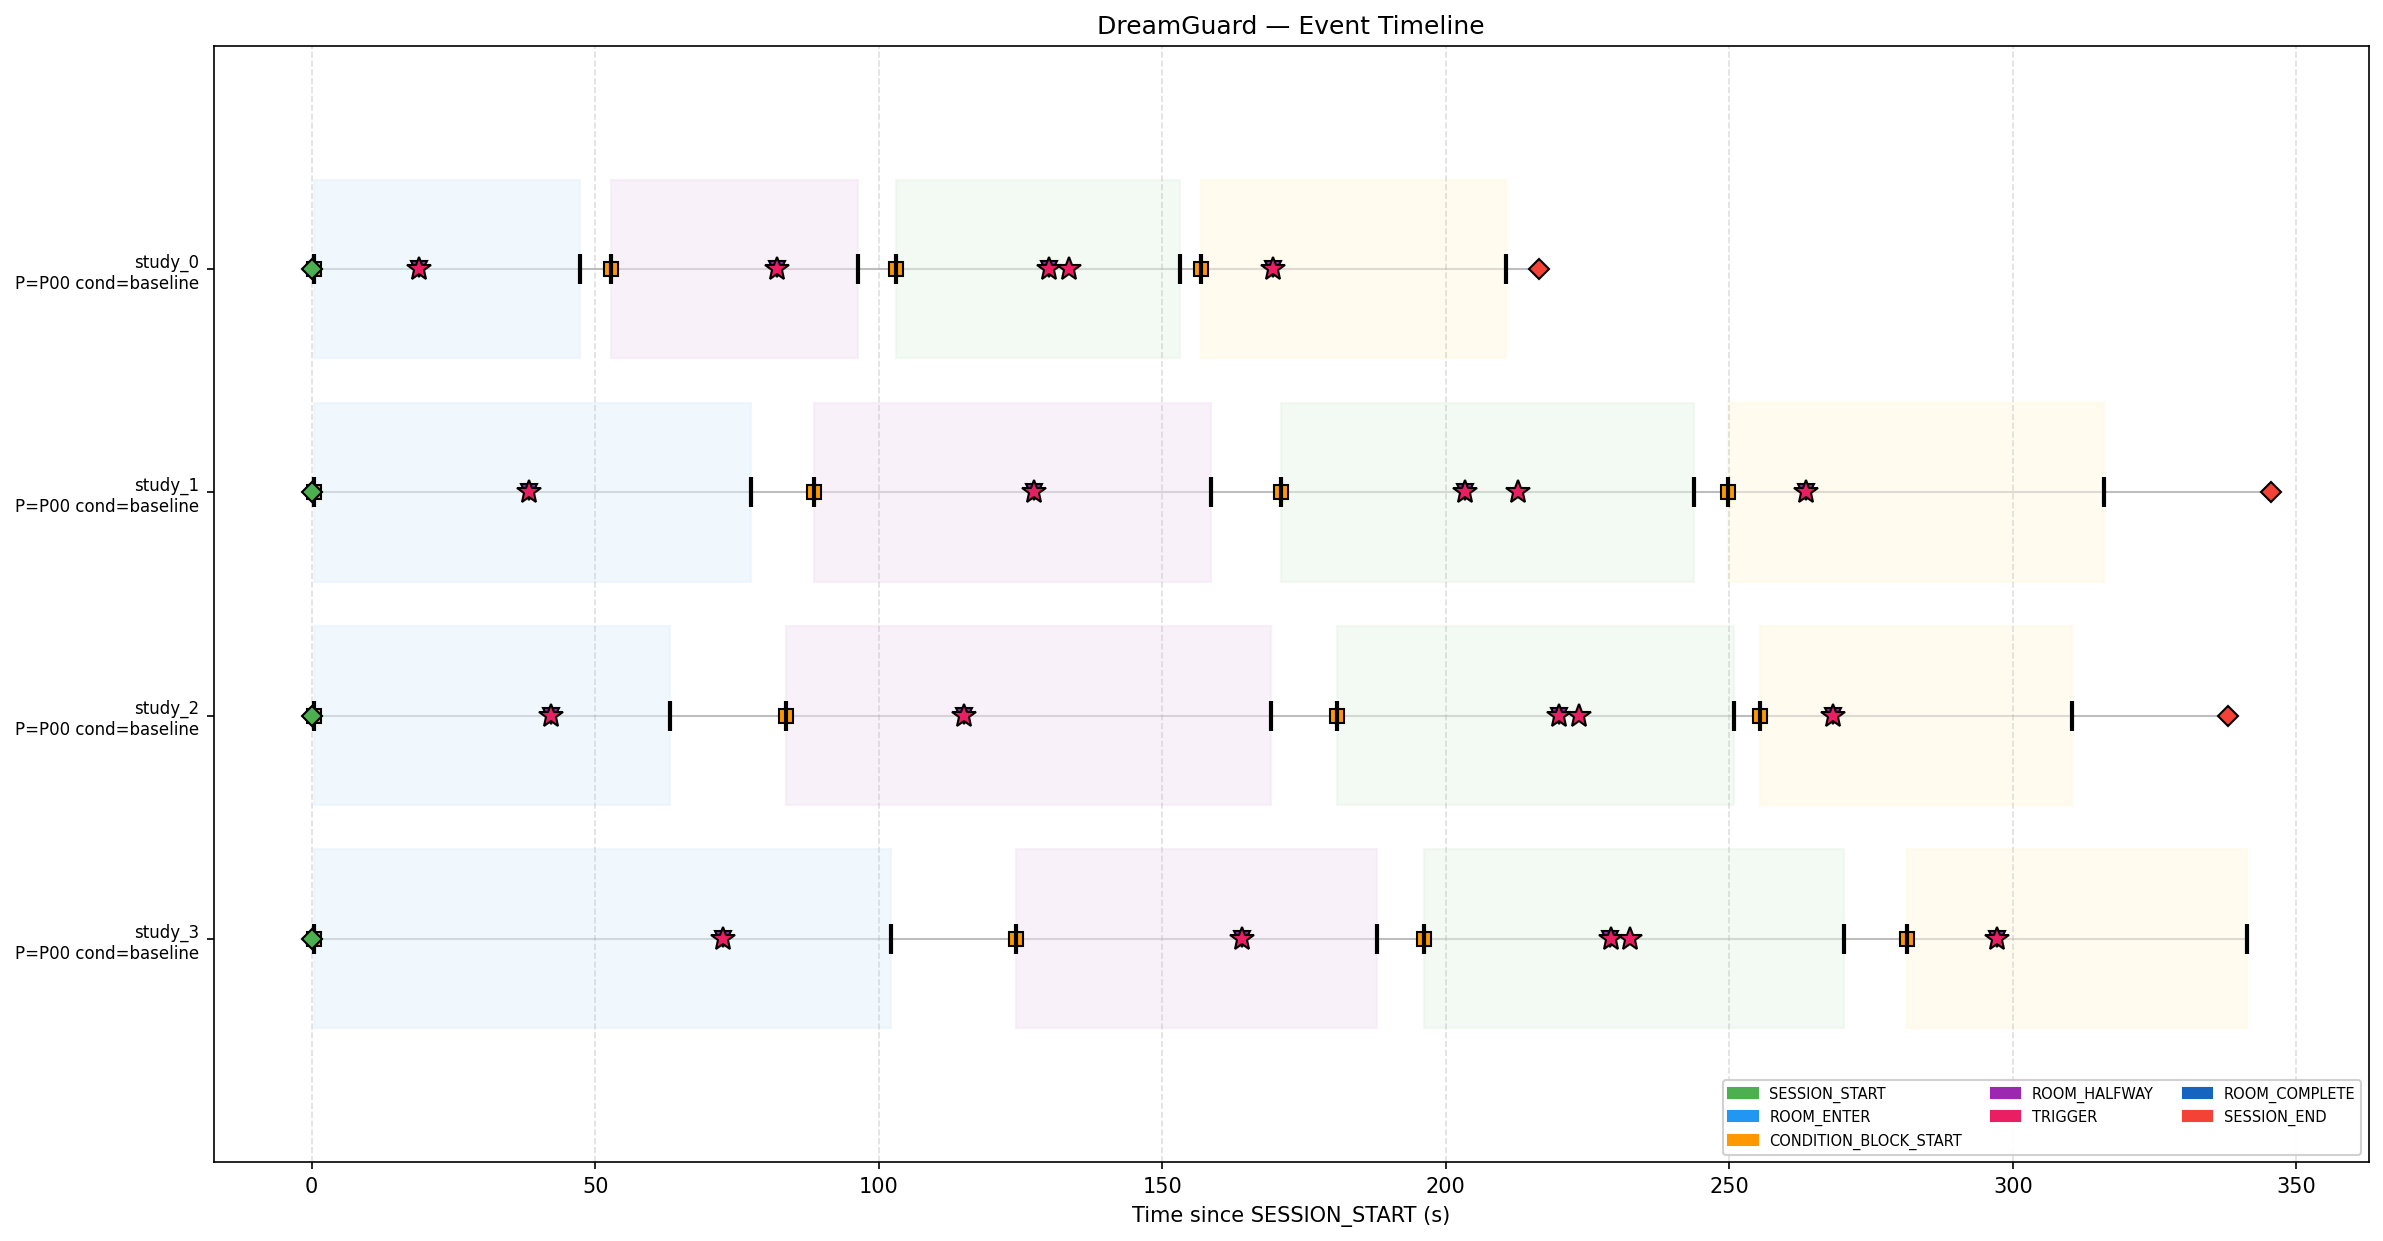

In [12]:
import subprocess, sys as _sys

ANALYSIS_DIR = SCRIPTS_DIR.parent / 'src' / 'analysis'
timeline_out = OUT_DIR / 'timeline.png'
result = subprocess.run(
    ['uv', 'run', str(ANALYSIS_DIR / 'timeline.py'), str(EXPERIMENTS_DIR), '--out', str(timeline_out)],
    capture_output=True, text=True, cwd=str(ANALYSIS_DIR)
)
print(result.stdout)
if result.stderr:
    print(result.stderr, file=_sys.stderr)
if timeline_out.exists():
    display(IPyImage(str(timeline_out)))

## Performance Metrics

FPS, frame time, and memory sampled every 0.5 s by `PerformanceLogger`.
Plots: time-series per session, per-condition box plots, and memory-over-time overlay.

Sessions with performance data: ['study_0', 'study_1', 'study_2', 'study_3']
  study_0: 432 samples  fps mean=62.7  allocated mean=265.8 MB
  study_1: 690 samples  fps mean=62.7  allocated mean=266.6 MB
  study_2: 675 samples  fps mean=72.8  allocated mean=265.9 MB
  study_3: 2500 samples  fps mean=71.4  allocated mean=286.8 MB


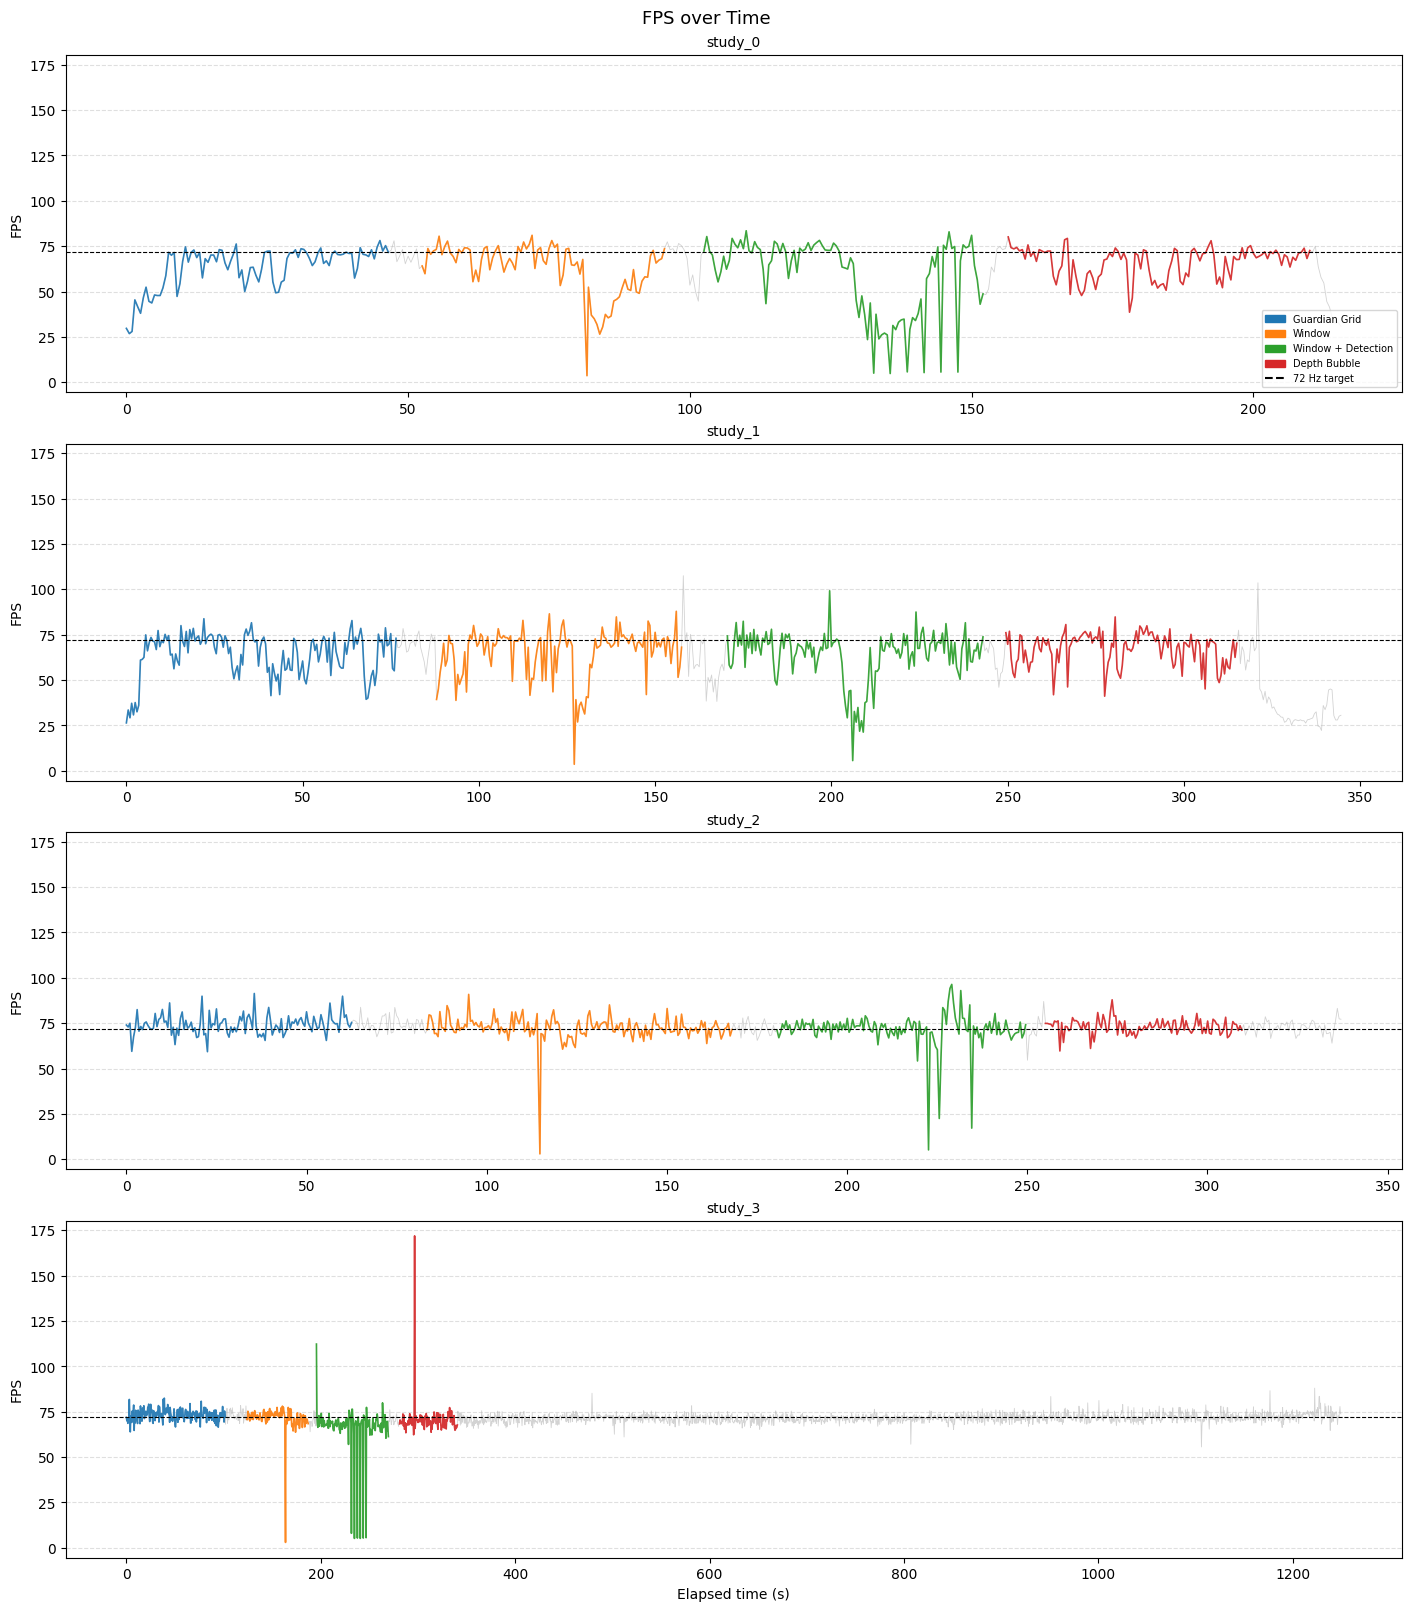

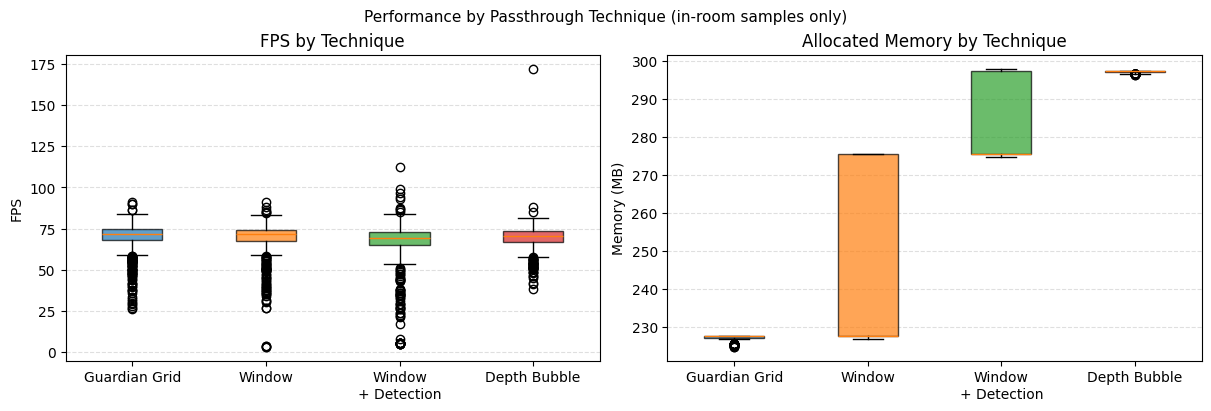

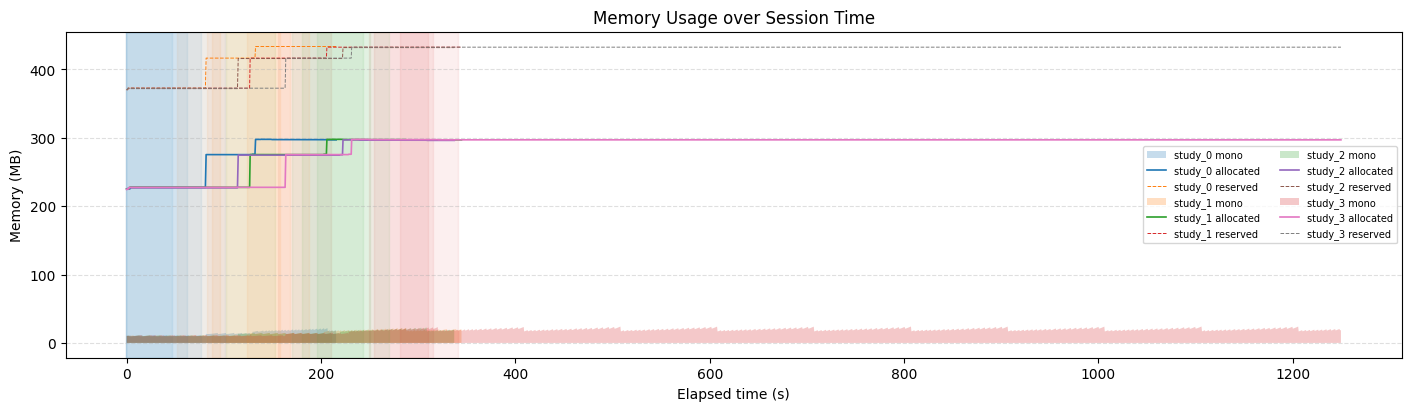

fps                     allocated_memory_mb         \
                     mean    std   min    max                mean    std   
technique                                                                  
Guardian Grid       69.40   9.60  26.4   91.4              227.36   0.52   
Window              68.63  11.15   3.0   90.9              249.92  23.85   
Window + Detection  65.53  15.20   4.8  112.3              285.53  11.08   
Depth Bubble        69.13   8.55  38.6  171.9              297.10   0.31   

                                   mono_used_mb                      
                       min     max         mean   std    min    max  
technique                                                            
Guardian Grid       224.61  227.67        10.37  0.45   9.58  11.35  
Window              226.86  275.51        11.90  1.64   9.73  14.71  
Window + Detection  274.68  297.96        15.66  2.07  12.88  19.92  
Depth Bubble        296.32  297.46        19.44  1.34  16.82  23.16

In [13]:
# ── Load and annotate performance data with room/technique ───────────────────
perf_data = {}
for name, d in data.items():
    perf = d.get('performance', pd.DataFrame())
    if perf.empty:
        continue

    perf = perf.copy()
    perf['session']   = name
    perf['elapsed_s'] = (perf['timestamp_iso'] - perf['timestamp_iso'].iloc[0]).dt.total_seconds()
    perf['room_id']   = pd.NA
    perf['technique'] = pd.NA

    rooms = d['rooms']
    if not rooms.empty:
        enters = rooms[rooms.event == 'ENTER'].set_index('room_id')['timestamp_iso']
        exits  = rooms[rooms.event == 'EXIT'].set_index('room_id')['timestamp_iso']
        for room_id in enters.index.intersection(exits.index):
            mask = (perf['timestamp_iso'] >= enters[room_id]) & \
                   (perf['timestamp_iso'] <= exits[room_id])
            perf.loc[mask, 'room_id']   = room_id
            perf.loc[mask, 'technique'] = ROOM_TECHNIQUE.get(room_id, room_id)

    perf_data[name] = perf

if not perf_data:
    print('No performance data found — check that performance.csv exists in each study_* folder.')
else:
    print(f'Sessions with performance data: {list(perf_data)}')
    for name, df in perf_data.items():
        print(f'  {name}: {len(df)} samples  '
              f'fps mean={df.fps.mean():.1f}  '
              f'allocated mean={df.allocated_memory_mb.mean():.1f} MB')

# ── Time-series: FPS per session — combined figure ────────────────────────────
if perf_data:
    room_colors = {rid: plt.cm.tab10.colors[i] for i, rid in enumerate(sorted(ROOM_TECHNIQUE))}
    sessions_ordered = list(perf_data.keys())
    n = len(sessions_ordered)

    fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), layout='constrained',
                             sharex=False, sharey=True)
    if n == 1:
        axes = [axes]
    fig.suptitle('FPS over Time', fontsize=13)

    legend_patches = None
    for ax, name in zip(axes, sessions_ordered):
        df = perf_data[name]
        ax.plot(df['elapsed_s'], df['fps'], color='lightgrey', lw=0.6, zorder=1)

        patches = []
        for room_id, tech in ROOM_TECHNIQUE.items():
            seg = df[df['room_id'] == room_id]
            if seg.empty:
                continue
            c = room_colors[room_id]
            ax.plot(seg['elapsed_s'], seg['fps'], color=c, lw=1.2, alpha=0.9, zorder=2)
            patches.append(mpatches.Patch(color=c, label=tech))

        ax.axhline(72, color='black', lw=0.8, ls='--')
        if legend_patches is None:
            legend_patches = patches + [Line2D([0],[0], color='black', ls='--', label='72 Hz target')]

        ax.set_title(name, fontsize=10)
        ax.set_ylabel('FPS')
        ax.grid(axis='y', linestyle='--', alpha=0.4)

    axes[-1].set_xlabel('Elapsed time (s)')
    if legend_patches:
        axes[0].legend(handles=legend_patches, fontsize=7, loc='lower right')

    plt.savefig(OUT_DIR / 'performance_timeseries_combined.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Per-technique box plots: FPS and allocated memory ────────────────────────
if perf_data:
    all_perf = pd.concat(perf_data.values(), ignore_index=True)
    in_room  = all_perf.dropna(subset=['technique'])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
    fig.suptitle('Performance by Passthrough Technique (in-room samples only)', fontsize=11)

    for ax, col, ylabel, title in [
        (axes[0], 'fps',                'FPS',         'FPS by Technique'),
        (axes[1], 'allocated_memory_mb', 'Memory (MB)', 'Allocated Memory by Technique'),
    ]:
        groups = [in_room[in_room.technique == t][col].dropna().values for t in TECHNIQUE_ORDER]
        bp = ax.boxplot(groups, labels=[t.replace(' + ', '\n+ ') for t in TECHNIQUE_ORDER],
                        patch_artist=True, notch=False)
        for patch, color in zip(bp['boxes'], plt.cm.tab10.colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.savefig(OUT_DIR / 'performance_by_technique.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Memory over time ──────────────────────────────────────────────────────────
if perf_data:
    fig, ax = plt.subplots(figsize=(14, 4), layout='constrained')
    for name, df in perf_data.items():
        ax.fill_between(df['elapsed_s'], df['mono_used_mb'],      alpha=0.25, label=f'{name} mono')
        ax.plot(df['elapsed_s'], df['allocated_memory_mb'], lw=1.2, label=f'{name} allocated')
        ax.plot(df['elapsed_s'], df['reserved_memory_mb'],  lw=0.7, ls='--', label=f'{name} reserved')

        rooms = data[name]['rooms']
        if not rooms.empty:
            enters = rooms[rooms.event == 'ENTER'].set_index('room_id')['timestamp_iso']
            exits  = rooms[rooms.event == 'EXIT'].set_index('room_id')['timestamp_iso']
            t0_sess = df['timestamp_iso'].iloc[0]
            for i, (room_id, tech) in enumerate(ROOM_TECHNIQUE.items()):
                if room_id not in enters.index or room_id not in exits.index:
                    continue
                x0 = (enters[room_id] - t0_sess).total_seconds()
                x1 = (exits[room_id]  - t0_sess).total_seconds()
                ax.axvspan(x0, x1, alpha=0.07, color=plt.cm.tab10.colors[i])

    ax.set_xlabel('Elapsed time (s)')
    ax.set_ylabel('Memory (MB)')
    ax.set_title('Memory Usage over Session Time')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.savefig(OUT_DIR / 'performance_memory.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Summary stats table ───────────────────────────────────────────────────────
if perf_data:
    all_perf = pd.concat(perf_data.values(), ignore_index=True)
    in_room  = all_perf.dropna(subset=['technique'])
    in_room['technique'] = pd.Categorical(in_room['technique'], categories=TECHNIQUE_ORDER, ordered=True)
    perf_summary = (
        in_room.groupby('technique', observed=True)[['fps', 'allocated_memory_mb', 'mono_used_mb']]
        .agg(['mean', 'std', 'min', 'max'])
        .round(2)
    )
    display(perf_summary)

## Export CSVs

In [14]:
for df, name in [
    (overview,   'summary.csv'),
    (latency_df, 'latency.csv') if not latency_df.empty else (None, None),
    (dur_df,     'room_durations.csv') if not dur_df.empty else (None, None),
]:
    if df is None:
        continue
    out = OUT_DIR / name
    df.to_csv(out, index=False)
    print(f'Saved → {out}')

if perf_data:
    all_perf = pd.concat(perf_data.values(), ignore_index=True)
    out = OUT_DIR / 'performance_summary.csv'
    all_perf.to_csv(out, index=False)
    print(f'Saved → {out}')


Saved → F:\Unity\Projects\DreamGuard\data\analysis\summary.csv
Saved → F:\Unity\Projects\DreamGuard\data\analysis\latency.csv
Saved → F:\Unity\Projects\DreamGuard\data\analysis\room_durations.csv
Saved → F:\Unity\Projects\DreamGuard\data\analysis\performance_summary.csv
